# Lab 6

You are tasked with evaluating card counting strategies for black jack. In order to do so, you will use object oriented programming to create a playable casino style black jack game where a computer dealer plays against $n$ computer players and possibily one human player. If you don't know the rules of blackjack or card counting, please google it. 

A few requirements:
* The game should utilize multiple 52-card decks. Typically the game is played with 6 decks.
* Players should have chips.
* Dealer's actions are predefined by rules of the game (typically hit on 16). 
* The players should be aware of all shown cards so that they can count cards.
* Each player could have a different strategy.
* The system should allow you to play large numbers of games, study the outcomes, and compare average winnings per hand rate for different strategies.

1. Begin by creating a classes to represent cards and decks. The deck should support more than one 52-card set. The deck should allow you to shuffle and draw cards. Include a "plastic" card, placed randomly in the deck. Later, when the plastic card is dealt, shuffle the cards before the next deal.

In [1]:
import random

class Card:
    SUITS = ['Hearts', 'Diamonds', 'Clubs', 'Spades']
    RANKS = ['2', '3', '4', '5', '6', '7', '8', '9', '10',
             'J', 'Q', 'K', 'A']

    VALUES = {
        '2': 2, '3': 3, '4': 4, '5': 5, '6': 6,
        '7': 7, '8': 8, '9': 9, '10': 10,
        'J': 10, 'Q': 10, 'K': 10, 'A': 11}

    def __init__(self, rank, suit):
        self.rank = rank
        self.suit = suit

    def value(self):
        return Card.VALUES[self.rank]

    def __repr__(self):
        return f"{self.rank} of {self.suit}"

class Deck:
    def __init__(self, num_decks=6):
        self.num_decks = num_decks
        self.cards = []
        self.cut_card_position = None
        self.needs_shuffle = False

        self.build_shoe()
        self.shuffle()

    def build_shoe(self): # build combined decks (shoe)
        self.cards = []

        for _ in range(self.num_decks):
            for suit in Card.SUITS:
                for rank in Card.RANKS:
                    self.cards.append(Card(rank, suit))

        # place cut card randomly in last 20% of shoe
        total_cards = len(self.cards)
        self.cut_card_position = random.randint(
            int(total_cards * 0.75),
            int(total_cards * 0.9))

    def shuffle(self): # shuffle cards and reset cut card trigger
        random.shuffle(self.cards)
        self.needs_shuffle = False

    def draw_card(self): # draw a card from  shoe
        if len(self.cards) == 0:
            raise ValueError("No cards left in deck.")

        card = self.cards.pop(0) # check if cut card reached
        if len(self.cards) <= self.cut_card_position:
            self.needs_shuffle = True

        return card

    def cards_remaining(self):
        return len(self.cards)

    def __repr__(self):
        return f"Deck with {len(self.cards)} cards remaining"

In [2]:
# test code

deck = Deck(num_decks=6)

for _ in range(10):
    print(deck.draw_card())

print("Cards remaining:", deck.cards_remaining())
print("Shuffle needed:", deck.needs_shuffle)

6 of Clubs
2 of Clubs
10 of Spades
9 of Spades
8 of Clubs
6 of Spades
10 of Clubs
K of Diamonds
8 of Diamonds
3 of Diamonds
Cards remaining: 302
Shuffle needed: False


2. Now design your game on a UML diagram. You may want to create classes to represent, players, a hand, and/or the game. As you work through the lab, update your UML diagram. At the end of the lab, submit your diagram (as pdf file) along with your notebook. 

In [33]:
# I used draw.io.
# I will submit my diagram as a pdf file along with this notebook. 
# I have 2 versions: version 1 is the first one I made when I worked on question 2.
# Version 2 is the updated one I revised when I worked through and finished this lab!

3. Begin with implementing the skeleton (ie define data members and methods/functions, but do not code the logic) of the classes in your UML diagram.

In [ ]:
class Card:

    def __init__(self, rank: str, suit: str):
        self.rank = rank
        self.suit = suit

    def value(self) -> int:
        pass

    def __repr__(self) -> str:
        pass

class Deck:

    def __init__(self, num_decks: int = 6):
        self.num_decks = num_decks
        self.cards = []
        self.cut_card_position = None
        self.needs_shuffle = False

    def build_shoe(self):
        pass

    def shuffle(self):
        pass

    def draw_card(self):
        pass

    def cards_remaining(self) -> int:
        pass

class Hand:

    def __init__(self):
        self.cards = []

    def add_card(self, card: Card):
        pass

    def value(self) -> int:
        pass

    def is_bust(self) -> bool:
        pass

    def is_blackjack(self) -> bool:
        pass

    def is_soft(self) -> bool:
        pass

class Player:

    def __init__(self, name: str, chips: int, strategy):
        self.name = name
        self.chips = chips
        self.strategy = strategy
        self.hands = []
        self.running_count = 0

    def place_bet(self) -> int:
        pass

    def play(self, hand: Hand, dealer_card: Card):
        pass

    def receive_card(self, card: Card):
        pass

    def update_count(self, card: Card):
        pass

class Dealer:

    def __init__(self):
        self.hand = Hand()

    def play(self, deck: Deck):
        pass

    def show_upcard(self) -> Card:
        pass


class BasicStrategy(Strategy):

    def decide_action(self, hand: Hand, dealer_card: Card):
        pass

    def bet_size(self, true_count: int) -> int:
        pass

class HiLoStrategy(Strategy):

    def __init__(self):
        self.true_count = 0

    def decide_action(self, hand: Hand, dealer_card: Card):
        pass

    def bet_size(self, true_count: int) -> int:
        pass

    def update_count(self, card: Card):
        pass

class RandomStrategy(Strategy):

    def decide_action(self, hand: Hand, dealer_card: Card):
        pass

    def bet_size(self, true_count: int) -> int:
        pass

class BlackjackGame:

    def __init__(self, players: list, num_decks: int = 6):
        self.deck = Deck(num_decks)
        self.players = players
        self.dealer = Dealer()
        self.statistics = {}
        self.num_rounds = 0

    def play_round(self):
        pass

    def deal_initial_cards(self):
        pass

    def player_turns(self):
        pass

    def dealer_turn(self):
        pass

    def resolve_bets(self):
        pass

    def collect_statistics(self):
        pass

    def simulate(self, rounds: int):
        pass

4. Complete the implementation by coding the logic of all functions. For now, just implement the dealer player and human player.

In [7]:
import random

class Card:

    VALUES = {
        '2': 2, '3': 3, '4': 4, '5': 5, '6': 6,
        '7': 7, '8': 8, '9': 9, '10': 10,
        'J': 10, 'Q': 10, 'K': 10, 'A': 11}

    def __init__(self, rank, suit):
        self.rank = rank
        self.suit = suit

    def value(self):
        return Card.VALUES[self.rank]

    def __repr__(self):
        return f"{self.rank} of {self.suit}"

class Deck: # desk/shoe

    SUITS = ["Hearts", "Diamonds", "Clubs", "Spades"]
    RANKS = ['2', '3', '4', '5', '6', '7',
             '8', '9', '10', 'J', 'Q', 'K', 'A']

    def __init__(self, num_decks=6):
        self.num_decks = num_decks
        self.cards = []
        self.cut_card_position = None
        self.needs_shuffle = False

        self.build_shoe()
        self.shuffle()

    def build_shoe(self):

        self.cards = []

        for _ in range(self.num_decks):
            for suit in Deck.SUITS:
                for rank in Deck.RANKS:
                    self.cards.append(Card(rank, suit))

        total = len(self.cards)

        # cut card in last ~20%
        self.cut_card_position = random.randint(
            int(total * 0.75),
            int(total * 0.9)
        )

    def shuffle(self):
        random.shuffle(self.cards)
        self.needs_shuffle = False

    def draw_card(self):

        card = self.cards.pop(0)

        if len(self.cards) <= self.cut_card_position:
            self.needs_shuffle = True

        return card

    def cards_remaining(self):
        return len(self.cards)

class Hand:

    def __init__(self):
        self.cards = []

    def add_card(self, card):
        self.cards.append(card)

    def value(self):

        total = 0
        aces = 0

        for card in self.cards:
            total += card.value()
            if card.rank == 'A':
                aces += 1

        # adjust ace from 11 → 1 if bust
        while total > 21 and aces:
            total -= 10
            aces -= 1

        return total

    def is_bust(self):
        return self.value() > 21

    def is_blackjack(self):
        return len(self.cards) == 2 and self.value() == 21

    def show(self):
        return ", ".join(str(c) for c in self.cards)

class Player:

    def __init__(self, name, chips=1000):
        self.name = name
        self.chips = chips
        self.hand = Hand()

    def place_bet(self):

        while True:
            bet = int(input(f"{self.name}, you have {self.chips} chips. Bet amount: "))
            if bet > 0 and bet <= self.chips:
                return bet
            print("Invalid bet.")

    def receive_card(self, card):
        self.hand.add_card(card)

    def play(self, deck):

        while True:

            print(f"\nYour hand: {self.hand.show()}")
            print(f"Value: {self.hand.value()}")

            if self.hand.is_bust():
                print("You busted!")
                break

            move = input("Hit or Stand? (h/s): ").lower()

            if move == 'h':
                card = deck.draw_card()
                print("You drew:", card)
                self.receive_card(card)

            elif move == 's':
                break

class Dealer:

    def __init__(self):
        self.hand = Hand()

    def receive_card(self, card):
        self.hand.add_card(card)

    def show_upcard(self):
        return self.hand.cards[0]

    def play(self, deck):

        print("\nDealer's turn...")
        print("Dealer hand:", self.hand.show())

        while self.hand.value() <= 16:
            card = deck.draw_card()
            print("Dealer hits:", card)
            self.receive_card(card)

        print("Dealer stands with:", self.hand.value())

class BlackjackGame:

    def __init__(self, player_name):

        self.deck = Deck(6)
        self.player = Player(player_name)
        self.dealer = Dealer()

    def deal_initial_cards(self):

        self.player.hand = Hand()
        self.dealer.hand = Hand()

        for _ in range(2):

            self.player.receive_card(self.deck.draw_card())
            self.dealer.receive_card(self.deck.draw_card())

    def resolve_bets(self, bet):

        player_val = self.player.hand.value()
        dealer_val = self.dealer.hand.value()

        print("\nFinal Hands")
        print("Player:", self.player.hand.show(), "=", player_val)
        print("Dealer:", self.dealer.hand.show(), "=", dealer_val)

        if self.player.hand.is_bust():
            print("Dealer wins.")
            self.player.chips -= bet

        elif self.dealer.hand.is_bust():
            print("Player wins!")
            self.player.chips += bet

        elif player_val > dealer_val:
            print("Player wins!")
            self.player.chips += bet

        elif player_val < dealer_val:
            print("Dealer wins.")
            self.player.chips -= bet

        else:
            print("Push.")

    def play_round(self):

        if self.deck.needs_shuffle:
            print("\n--- Reshuffling Shoe ---")
            self.deck.build_shoe()
            self.deck.shuffle()

        bet = self.player.place_bet()

        self.deal_initial_cards()

        print("\nDealer shows:", self.dealer.show_upcard())

        print("Your hand:", self.player.hand.show())

        # player turn
        self.player.play(self.deck)

        # dealer turn if player not bust
        if not self.player.hand.is_bust():
            self.dealer.play(self.deck)

        self.resolve_bets(bet)

    def play(self):

        while self.player.chips > 0:

            self.play_round()

            again = input("\nPlay another round? (y/n): ").lower()

            if again != 'y':
                break

        print("\nGame Over. Chips:", self.player.chips)

if __name__ == "__main__":

    name = input("Enter your name: ")

    game = BlackjackGame(name)

    game.play()

Enter your name:  Leslye
Leslye, you have 1000 chips. Bet amount:  100



Dealer shows: Q of Spades
Your hand: 4 of Diamonds, 9 of Spades

Your hand: 4 of Diamonds, 9 of Spades
Value: 13


Hit or Stand? (h/s):  h


You drew: 7 of Diamonds

Your hand: 4 of Diamonds, 9 of Spades, 7 of Diamonds
Value: 20


Hit or Stand? (h/s):  s



Dealer's turn...
Dealer hand: Q of Spades, Q of Clubs
Dealer stands with: 20

Final Hands
Player: 4 of Diamonds, 9 of Spades, 7 of Diamonds = 20
Dealer: Q of Spades, Q of Clubs = 20
Push.



Play another round? (y/n):  n



Game Over. Chips: 1000


5.  Test. Demonstrate game play. For example, create a game of several dealer players and show that the game is functional through several rounds.

In [14]:
class DealerPlayer(Player):

    def place_bet(self):
        bet = 50
        return min(bet, self.chips)

    def play(self, deck):

        while self.hand.value() <= 16:
            card = deck.draw_card()
            self.receive_card(card)

# supports multiple players
class BlackjackGame:

    def __init__(self, players):

        self.deck = Deck(6)
        self.players = players
        self.dealer = Dealer()

# deal cards to all players
def deal_initial_cards(self):

    self.dealer.hand = Hand()

    for p in self.players:
        p.hand = Hand()

    for _ in range(2):

        for p in self.players:
            p.receive_card(self.deck.draw_card())

        self.dealer.receive_card(self.deck.draw_card())

# player turns
def player_turns(self):

    for p in self.players:

        if not p.hand.is_bust():
            p.play(self.deck)

# resolve bets for each player
def resolve_bets(self):

    dealer_val = self.dealer.hand.value()

    for p in self.players:

        bet = p.place_bet()
        player_val = p.hand.value()

        if p.hand.is_bust():
            p.chips -= bet

        elif self.dealer.hand.is_bust():
            p.chips += bet

        elif player_val > dealer_val:
            p.chips += bet

        elif player_val < dealer_val:
            p.chips -= bet

# play a round
def play_round(self):

    if self.deck.needs_shuffle:
        self.deck.build_shoe()
        self.deck.shuffle()

    self.deal_initial_cards()

    self.player_turns()

    self.dealer.play(self.deck)

    self.resolve_bets()

In [ ]:
# test sim
players = [
    DealerPlayer("Bot1", 1000),
    DealerPlayer("Bot2", 1000),
    DealerPlayer("Bot3", 1000),
    DealerPlayer("Bot4", 1000)
]

game = BlackjackGame(players)

for i in range(5):

    print("\n----------------------")
    print("Round", i + 1)
    print("----------------------")

    game.play_round()

    for p in players:
        print(p.name, "chips:", p.chips)

6. Implement a new player with the following strategy:

    * Assign each card a value: 
        * Cards 2 to 6 are +1 
        * Cards 7 to 9 are 0 
        * Cards 10 through Ace are -1
    * Compute the sum of the values for all cards seen so far.
    * Hit if sum is very negative, stay if sum is very positive. Select a threshold for hit/stay, e.g. 0 or -2.  

In [16]:
class CountingPlayer(Player):

    def __init__(self, name, chips=1000, threshold=0):
        super().__init__(name, chips)
        self.running_count = 0
        self.threshold = threshold

    # update running count whenever a card is seen
    def update_count(self, card):

        if card.rank in ['2','3','4','5','6']:
            self.running_count += 1

        elif card.rank in ['7','8','9']:
            self.running_count += 0

        else:  # 10, J, Q, K, A
            self.running_count -= 1


    def place_bet(self):
        bet = 50
        return min(bet, self.chips)


    def receive_card(self, card):
        self.hand.add_card(card)
        self.update_count(card)


    def play(self, deck):

        print(f"\n{self.name} hand:", self.hand.show(),
              "| value:", self.hand.value(),
              "| count:", self.running_count)

        while True:

            if self.hand.value() > 21:
                break

            # strategy decision
            if self.running_count <= self.threshold:

                card = deck.draw_card()
                print(self.name, "hits:", card)

                self.receive_card(card)

            else:
                print(self.name, "stands")
                break

In [17]:
def deal_initial_cards(self):

    self.dealer.hand = Hand()

    for p in self.players:
        p.hand = Hand()

    for _ in range(2):

        for p in self.players:
            card = self.deck.draw_card()
            p.receive_card(card)

        card = self.deck.draw_card()
        self.dealer.receive_card(card)

        # allow players to see dealer card
        for p in self.players:
            if hasattr(p, "update_count"):
                p.update_count(card)

7. Create a test scenario where one player, using the above strategy, is playing with a dealer and 3 other players that follow the dealer's strategy. Each player starts with same number of chips. Play 50 rounds (or until the strategy player is out of money). Compute the strategy player's winnings. You may remove unnecessary printouts from your code (perhaps implement a verbose/quiet mode) to reduce the output.

In [19]:
# dealer strategy player
class DealerPlayer(Player):

    def place_bet(self):
        return min(50, self.chips)

    def play(self, deck):

        while self.hand.value() <= 16:
            self.receive_card(deck.draw_card())

# counting strategy player
class CountingPlayer(Player):

    def __init__(self, name, chips=1000, threshold=0):
        super().__init__(name, chips)
        self.running_count = 0
        self.threshold = threshold

    def update_count(self, card):

        if card.rank in ['2','3','4','5','6']:
            self.running_count += 1

        elif card.rank in ['10','J','Q','K','A']:
            self.running_count -= 1

    def place_bet(self):
        return min(50, self.chips)

    def receive_card(self, card):
        self.hand.add_card(card)
        self.update_count(card)

    def play(self, deck):

        while self.hand.value() <= 21:

            if self.running_count <= self.threshold:
                self.receive_card(deck.draw_card())
            else:
                break

In [ ]:
# test scenario
# starting chips
starting_chips = 1000

counter = CountingPlayer("StrategyPlayer", starting_chips)
p1 = DealerPlayer("Bot1", starting_chips)
p2 = DealerPlayer("Bot2", starting_chips)
p3 = DealerPlayer("Bot3", starting_chips)

players = [counter, p1, p2, p3]

game = BlackjackGame(players, verbose=False)

rounds = 50

for i in range(rounds):

    if counter.chips <= 0:
        print("Strategy player is out of chips.")
        break

    game.play_round()

print("\nSimulation Complete")
print("Rounds played:", i+1)

winnings = counter.chips - starting_chips

print("Strategy Player Final Chips:", counter.chips)
print("Strategy Player Winnings:", winnings)

8. Create a loop that runs 100 games of 50 rounds, as setup in previous question, and store the strategy player's chips at the end of the game (aka "winnings") in a list. Histogram the winnings. What is the average winnings per round? What is the standard deviation. What is the probabilty of net winning or lossing after 50 rounds?


In [25]:
class BlackjackGame:

    def __init__(self, players, verbose=False):
        self.players = players
        self.dealer = Dealer()
        self.deck = Deck(6)
        self.verbose = verbose

    def deal_initial_cards(self):

        self.dealer.hand = Hand()

        for p in self.players:
            p.hand = Hand()

        for _ in range(2):

            for p in self.players:
                card = self.deck.draw_card()
                p.receive_card(card)

            card = self.deck.draw_card()
            self.dealer.receive_card(card)

            # allow counting players to see dealer cards
            for p in self.players:
                if hasattr(p, "update_count"):
                    p.update_count(card)

    def player_turns(self):

        for p in self.players:
            if not p.hand.is_bust():
                p.play(self.deck)

    def dealer_turn(self):

        while self.dealer.hand.value() <= 16:
            self.dealer.receive_card(self.deck.draw_card())

    def resolve_bets(self):

        dealer_value = self.dealer.hand.value()

        for p in self.players:

            bet = p.place_bet()
            player_value = p.hand.value()

            if p.hand.is_bust():
                p.chips -= bet

            elif self.dealer.hand.is_bust():
                p.chips += bet

            elif player_value > dealer_value:
                p.chips += bet

            elif player_value < dealer_value:
                p.chips -= bet

    def play_round(self):

        if self.deck.needs_shuffle:
            self.deck.build_shoe()
            self.deck.shuffle()

        self.deal_initial_cards()
        self.player_turns()
        self.dealer_turn()

        self.resolve_bets()

In [26]:
import numpy as np
import matplotlib.pyplot as plt

num_games = 100
rounds_per_game = 50
starting_chips = 1000

winnings_list = []

for g in range(num_games):

    counter = CountingPlayer("StrategyPlayer", starting_chips)
    p1 = DealerPlayer("Bot1", starting_chips)
    p2 = DealerPlayer("Bot2", starting_chips)
    p3 = DealerPlayer("Bot3", starting_chips)

    players = [counter, p1, p2, p3]

    game = BlackjackGame(players, verbose=False)

    for r in range(rounds_per_game):

        if counter.chips <= 0:
            break

        game.play_round()

    winnings = counter.chips - starting_chips
    winnings_list.append(winnings)

winnings_array = np.array(winnings_list)

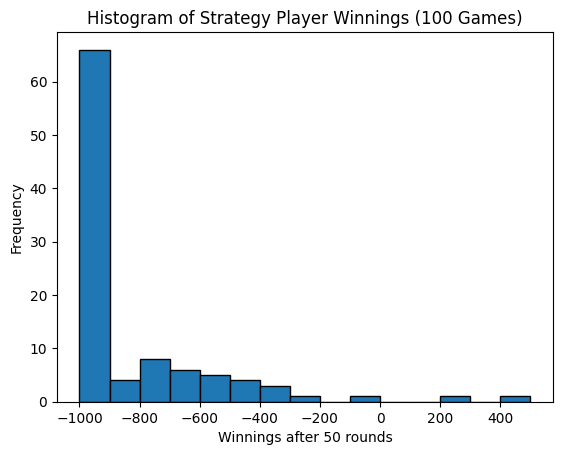

In [27]:
plt.hist(winnings_array, bins=15, edgecolor="black")
plt.title("Histogram of Strategy Player Winnings (100 Games)")
plt.xlabel("Winnings after 50 rounds")
plt.ylabel("Frequency")
plt.show()

In [28]:
avg_winnings_per_game = np.mean(winnings_array)
avg_winnings_per_round = avg_winnings_per_game / rounds_per_game

std_dev = np.std(winnings_array)

prob_win = np.sum(winnings_array > 0) / num_games
prob_loss = np.sum(winnings_array < 0) / num_games

print("Average winnings per game:", avg_winnings_per_game)
print("Average winnings per round:", avg_winnings_per_round)

print("Standard deviation:", std_dev)

print("Probability of net win:", prob_win)
print("Probability of net loss:", prob_loss)

Average winnings per game: -850.5
Average winnings per round: -17.01
Standard deviation: 270.69309189560045
Probability of net win: 0.02
Probability of net loss: 0.98


9. Repeat previous questions scanning the value of the threshold. Try at least 5 different threshold values. Can you find an optimal value?

In [29]:
import numpy as np
import matplotlib.pyplot as plt

thresholds = [-5, -2, 0, 2, 5]
results = {}

num_games = 100
rounds_per_game = 50
starting_chips = 1000

for threshold in thresholds:

    winnings_list = []

    for g in range(num_games):

        counter = CountingPlayer(
            "StrategyPlayer",
            starting_chips,
            threshold=threshold
        )

        p1 = DealerPlayer("Bot1", starting_chips)
        p2 = DealerPlayer("Bot2", starting_chips)
        p3 = DealerPlayer("Bot3", starting_chips)

        players = [counter, p1, p2, p3]

        game = BlackjackGame(players)

        for r in range(rounds_per_game):

            if counter.chips <= 0:
                break

            game.play_round()

        winnings = counter.chips - starting_chips
        winnings_list.append(winnings)

    winnings_array = np.array(winnings_list)

    avg_per_game = np.mean(winnings_array)
    avg_per_round = avg_per_game / rounds_per_game
    std_dev = np.std(winnings_array)
    prob_win = np.sum(winnings_array > 0) / num_games
    prob_loss = np.sum(winnings_array < 0) / num_games

    results[threshold] = {
        "avg_per_round": avg_per_round,
        "std_dev": std_dev,
        "prob_win": prob_win,
        "prob_loss": prob_loss
    }

    print(f"\nThreshold = {threshold}")
    print("Avg per round:", avg_per_round)
    print("Std dev:", std_dev)
    print("P(win):", prob_win)
    print("P(loss):", prob_loss)


Threshold = -5
Avg per round: -13.24
Std dev: 337.2032028317643
P(win): 0.04
P(loss): 0.95

Threshold = -2
Avg per round: -14.82
Std dev: 337.37071597872864
P(win): 0.02
P(loss): 0.97

Threshold = 0
Avg per round: -17.41
Std dev: 246.58619182752307
P(win): 0.0
P(loss): 1.0

Threshold = 2
Avg per round: -17.67
Std dev: 252.3940371720378
P(win): 0.02
P(loss): 0.98

Threshold = 5
Avg per round: -19.3
Std dev: 100.37429949942366
P(win): 0.0
P(loss): 1.0


In [30]:
# finding optimal threshold
best_threshold = max(
    thresholds,
    key=lambda t: results[t]["avg_per_round"]
)

print("\nOptimal Threshold:", best_threshold)
print("Best Avg Per Round:",
      results[best_threshold]["avg_per_round"])


Optimal Threshold: -5
Best Avg Per Round: -13.24


10. Create a new strategy based on web searches or your own ideas. Demonstrate that the new strategy will result in increased or decreased winnings. 

In [31]:
class TrueCountStrategyPlayer(Player):

    def __init__(self, name, chips=1000):
        super().__init__(name, chips)
        self.running_count = 0

    def update_count(self, card):

        if card.rank in ['2','3','4','5','6']:
            self.running_count += 1
        elif card.rank in ['10','J','Q','K','A']:
            self.running_count -= 1

    def decks_remaining(self, deck):
        return max(1, len(deck.cards) / 52)

    def true_count(self, deck):
        return self.running_count / self.decks_remaining(deck)

    def place_bet(self, deck):

        tc = self.true_count(deck)

        if tc >= 2:
            bet = 100
        elif tc <= 0:
            bet = 10
        else:
            bet = 50

        return min(bet, self.chips)

    def receive_card(self, card):
        self.hand.add_card(card)
        self.update_count(card)

    def play(self, deck):

        while self.hand.value() <= 21:

            tc = self.true_count(deck)

            if tc <= 0:
                self.receive_card(deck.draw_card())
            else:
                break

In [32]:
# ChatGPT helped me a lot.